In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rushikeshhande0809/electric-vehicle-sales-by-state-in-india-csv/Electric Vehicle Sales by State in India.csv


In [3]:
path = "/kaggle/input/datasets/rushikeshhande0809/electric-vehicle-sales-by-state-in-india-csv/Electric Vehicle Sales by State in India.csv"

df = pd.read_csv(path)

df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [4]:
df.shape

(96845, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

In [7]:
# Convert Year to integer
df['Year'] = df['Year'].astype(int)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014,jan,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014,jan,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014,jan,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014,jan,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014,jan,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0.0


In [8]:
# Extract month and day from date

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Month,Day
0,2014,jan,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0,1,1
1,2014,jan,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0,1,1
2,2014,jan,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0.0,1,1
3,2014,jan,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0,1,1
4,2014,jan,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0.0,1,1


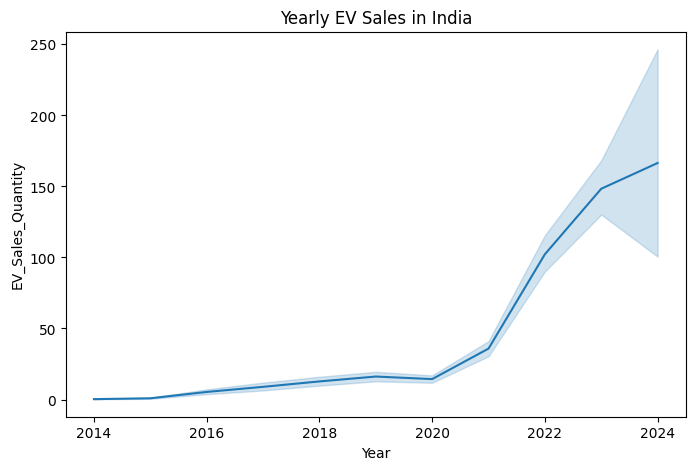

In [9]:
plt.figure(figsize=(8,5))

sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df)

plt.title("Yearly EV Sales in India")
plt.show()

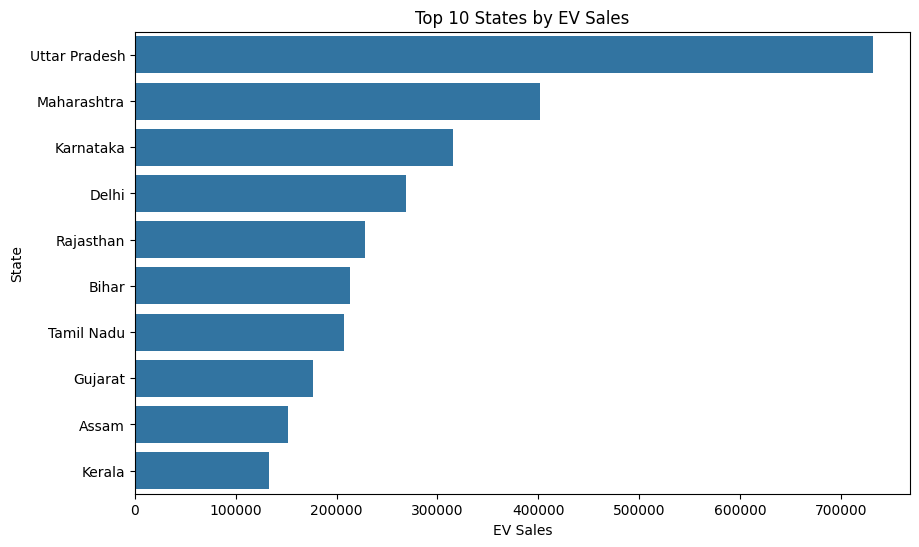

In [10]:
plt.figure(figsize=(10,6))

state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=state_sales.values, y=state_sales.index)

plt.title("Top 10 States by EV Sales")
plt.xlabel("EV Sales")
plt.ylabel("State")

plt.show()

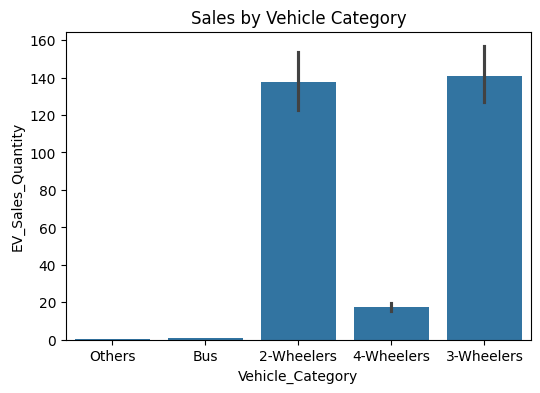

In [11]:
plt.figure(figsize=(6,4))

sns.barplot(x='Vehicle_Category', y='EV_Sales_Quantity', data=df)

plt.title("Sales by Vehicle Category")

plt.show()

In [12]:
df_encoded = pd.get_dummies(df, columns=[
    'State',
    'Vehicle_Class',
    'Vehicle_Category',
    'Vehicle_Type'
], drop_first=True)

df_encoded = df_encoded.drop(['Date','Month_Name'], axis=1)

df_encoded.head()

,Year,EV_Sales_Quantity,Month,Day,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,State_Chandigarh,State_Chhattisgarh,...,Vehicle_Type_3W_Goods,Vehicle_Type_3W_Goods_LowSpeed,Vehicle_Type_3W_Personal,Vehicle_Type_3W_Shared,Vehicle_Type_3W_Shared_LowSpeed,Vehicle_Type_4W_Personal,Vehicle_Type_4W_Shared,Vehicle_Type_Bus,Vehicle_Type_Institution Bus,Vehicle_Type_Others
0,2014,0.0,1,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2014,0.0,1,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2014,0.0,1,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2014,0.0,1,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2014,0.0,1,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [13]:
X = df_encoded.drop('EV_Sales_Quantity', axis=1)

y = df_encoded['EV_Sales_Quantity']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 130.58175227721011
R2 Score: 0.934519365497295


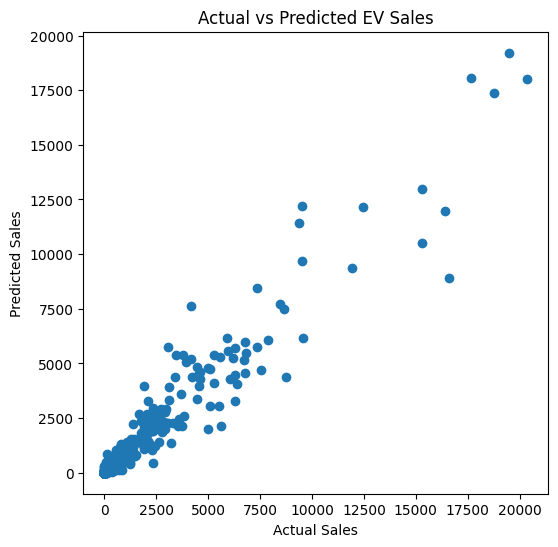

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted EV Sales")

plt.show()

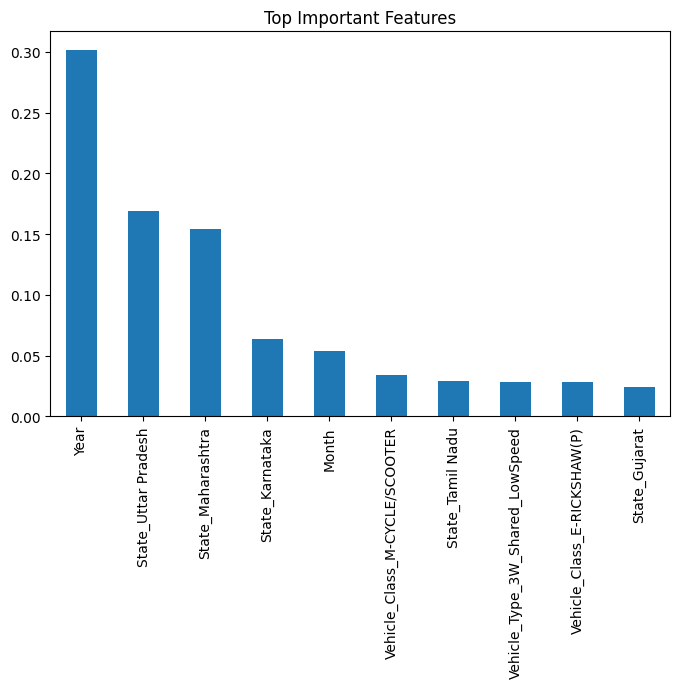

In [19]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

importance.plot(kind='bar')

plt.title("Top Important Features")

plt.show()

**Conclusion**

This project analyzed Electric Vehicle sales across different states in India.

Key Insights:
- EV sales have increased significantly in recent years.
- Some states contribute the majority of EV adoption.
- Vehicle category and state are strong predictors of EV sales.

Machine Learning Model:
A Random Forest Regressor model was used to predict EV sales quantity.
The model achieved a good R2 score, showing it can effectively estimate EV sales based on historical patterns.

This analysis can help policymakers and businesses understand EV market trends and plan infrastructure accordingly.